# Terrain ruggedness

Standard deviation of surface elevation (metres) within each 0.5° grid cell, sourced from NOAA ETOPO 2022 (60 arc-second global DEM). Higher = more mountainous / uneven terrain, lower = flat. Ocean cells are masked to `NaN` using `is_land` from `grid.nc`.

In [6]:
import numpy as np
import xarray as xr

from helpers import RAW_DIR, load_grid, save_variable

VARIABLE = 'terrain_ruggedness'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

## 1. Fetch raw data

NOAA ETOPO 2022 v1 at 60 arc-second (~2 km) surface elevation, single NetCDF (~450 MB). At 0.5° target resolution that's ~30×30 = 900 elevation samples per cell — more than enough to characterise ruggedness. Downloaded once and cached under `variable_raw`.

In [7]:
URL = 'https://www.ngdc.noaa.gov/thredds/fileServer/global/ETOPO2022/60s/60s_surface_elev_netcdf/ETOPO_2022_v1_60s_N90W180_surface.nc'
nc_path = variable_raw / 'ETOPO_2022_v1_60s_N90W180_surface.nc'

if not nc_path.exists():
    print(f'downloading {URL}')
    from helpers import download
    await download(URL,nc_path) 

print(f'{nc_path.name}: {nc_path.stat().st_size / 1024**2:.0f} MB')

downloading https://www.ngdc.noaa.gov/thredds/fileServer/global/ETOPO2022/60s/60s_surface_elev_netcdf/ETOPO_2022_v1_60s_N90W180_surface.nc


https://www.ngdc.noaa.gov/thredds/fileServer/global/ETOPO2022/60s/60s_surface_elev_netcdf/ETOPO_2022_v1_60s_N90W180_surface.nc: 456MB [11:20, 703kB/s]  

ETOPO_2022_v1_60s_N90W180_surface.nc: 456 MB


## 2. Clean & transform

Open the DEM and pick out the elevation variable in metres. ETOPO 2022 stores it as `z` on `(lat, lon)`; sibling ETOPO files sometimes use `elevation` / `latitude` / `longitude`, so we normalise the names before proceeding. Latitude is flipped to ascending order if needed so `coarsen` and `interp` behave predictably.

In [8]:
etopo = xr.open_dataset(nc_path)

rename = {}
if 'latitude' in etopo.dims:
    rename['latitude'] = 'lat'
if 'longitude' in etopo.dims:
    rename['longitude'] = 'lon'
if rename:
    etopo = etopo.rename(rename)

elev_name = 'z' if 'z' in etopo.data_vars else 'elevation'
elev = etopo[elev_name].astype('float32')

if elev.lat.values[0] > elev.lat.values[-1]:
    elev = elev.reindex(lat=elev.lat[::-1])

print(elev)

<xarray.DataArray 'z' (lat: 10800, lon: 21600)> Size: 933MB
array([[ 2832.3396,  2832.2747,  2832.2568, ...,  2832.2834,  2832.2617,
         2831.8252],
       [ 2832.9805,  2833.5068,  2833.532 , ...,  2833.586 ,  2833.6218,
         2832.8164],
       [ 2835.7395,  2838.4072,  2838.686 , ...,  2838.3325,  2838.1938,
         2836.0889],
       ...,
       [-4211.    , -4211.    , -4216.501 , ..., -4211.    , -4211.    ,
        -4211.    ],
       [-4219.    , -4219.    , -4219.    , ..., -4219.    , -4219.    ,
        -4219.    ],
       [-4153.25  , -4153.25  , -4153.4375, ..., -4153.    , -4153.    ,
        -4153.0625]], shape=(10800, 21600), dtype=float32)
Coordinates:
  * lat      (lat) float64 86kB -89.99 -89.97 -89.96 ... 89.96 89.97 89.99
  * lon      (lon) float64 173kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
Attributes:
    long_name:      z
    grid_mapping:   crs
    units:          meters
    positive:       up
    standard_name:  height
    vert_crs_name:  EGM2008

## 3. Interpolate onto the grid

For each ~0.5° window in the DEM, take the standard deviation of elevation — the standard "terrain ruggedness" proxy. `coarsen` with `boundary='trim'` drops the fractional row/column at the pole edge, then `interp(method='nearest')` snaps the coarsened field onto the actual `grid.lat` / `grid.lon`. Finally, ocean cells are masked out.

In [ ]:


%pip install scipy

grid = load_grid()

target_lat_step = float(abs(grid.lat[1] - grid.lat[0]))
target_lon_step = float(abs(grid.lon[1] - grid.lon[0]))

lat_factor = max(1, round(target_lat_step / float(abs(elev.lat[1] - elev.lat[0]))))
lon_factor = max(1, round(target_lon_step / float(abs(elev.lon[1] - elev.lon[0]))))

ruggedness = elev.coarsen(lat=lat_factor, lon=lon_factor, boundary='trim').std()

values = (
    ruggedness
    .interp(lat=grid.lat, lon=grid.lon, method='nearest')
    .astype('float32')
    .rename(VARIABLE)
    .where(grid.is_land == 1)
)

  Using cached scipy-1.18.0-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
Using cached scipy-1.18.0-cp312-cp312-macosx_14_0_arm64.whl (20.4 MB)
Note: you may need to restart the kernel to use updated packages.


## 4. Plot

<Axes: title={'center': 'terrain_ruggedness'}, xlabel='longitude', ylabel='latitude'>

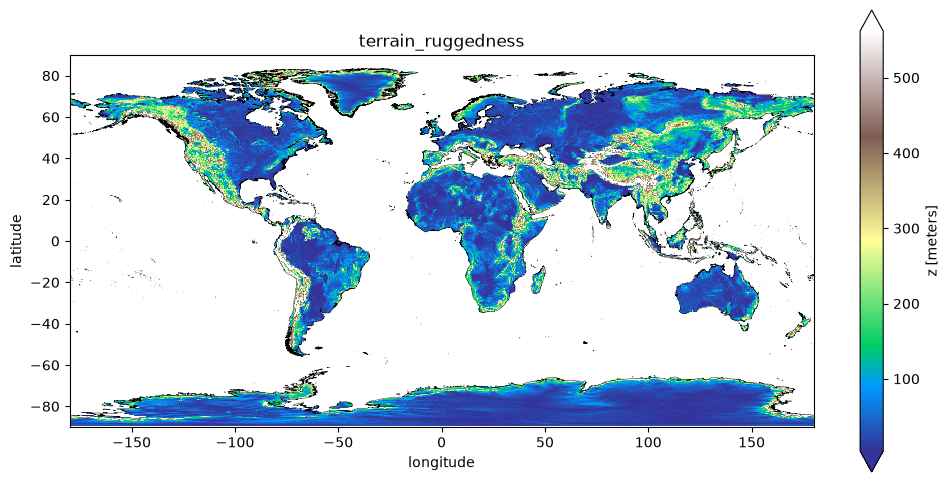

In [11]:
from helpers import plot_map

plot_map(values, cmap='terrain', robust=True)

## 5. Save

In [12]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/terrain_ruggedness.nc
